# Avellaneda-Stoikov Strategy

## Lighter backtesting

In [12]:
import sys
import math
import numpy as np
from pathlib import Path

# Корень репо = ближайший предок cwd с .git. Кладём на путь и его (для backtesting),
# и research/ (для tools) — до импортов ниже.
here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / ".git").exists())
for path in (str(ROOT), str(ROOT / "research")):
    if path not in sys.path:
        sys.path.insert(0, path)

from tools import ROOT   # переопределяет ROOT корректным путём из tools/__init__.py
from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

CAPITAL = 5000.0  # USD

In [13]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q):
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        return [
            ("bid", r - half_spread, self.Q),
            ("ask", r + half_spread, self.Q),
        ]

In [14]:
hours = range(0, 24)  # 3 часа DOGE — быстрый прогон; расширь диапазон при желании
lob_paths    = [ROOT / f"data/lighter/DOGE/lob/20260712/{h:02d}.parquet"      for h in hours]
trades_paths = [ROOT / f"data/lighter/DOGE/trades/20260712/{h:02d}.jsonl.zst" for h in hours]

feed = LighterFeed(lob_paths, trades_paths)
feed

LighterFeed(lob=280,858 snapshots [2026-07-12 00:00:00.042000 → 2026-07-12 23:59:59.746000], trades=1,093 [2026-07-12 00:00:31.945000 → 2026-07-12 23:56:08.242000])

In [15]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 30
lob snapshots : 280,858  (crossed/locked: 0)
trades        : 1,093  (sells: 629)
invariants OK


In [16]:
# PnL пока не показателен: без комиссий/латентности/tick-rounding (следующие итерации).
# Цель прогона — движок гоняется на реальных данных Lighter и инварианты держатся.
params = {"sigma": 1e-06, "kappa": 1e6, "gamma": 0.01, "T": 14400.0, "Q": 100.0}
prefix = "/tmp/_lighter_dod"

bt = Backtester(log_interval_sec=10.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [17]:
s = BacktestResult(prefix, capital=CAPITAL)
display(s.summary_df())

value
group     metric                       
PnL       total_pnl ($)         -5.7568
          total_pnl (%)        -0.1151%
          sharpe_annualized      -27.10
          max_drawdown ($)      -7.4511
          max_drawdown (%)     -0.1490%
Fills     n_fills                   693
          n_bid_fills               352
          n_ask_fills               341
          fill_imbalance        +0.0159
Inventory avg_inventory      -2037.6023
          std_inventory       2693.1766
          max_abs_inventory   4907.0000
          turnover ($)         4,952.12

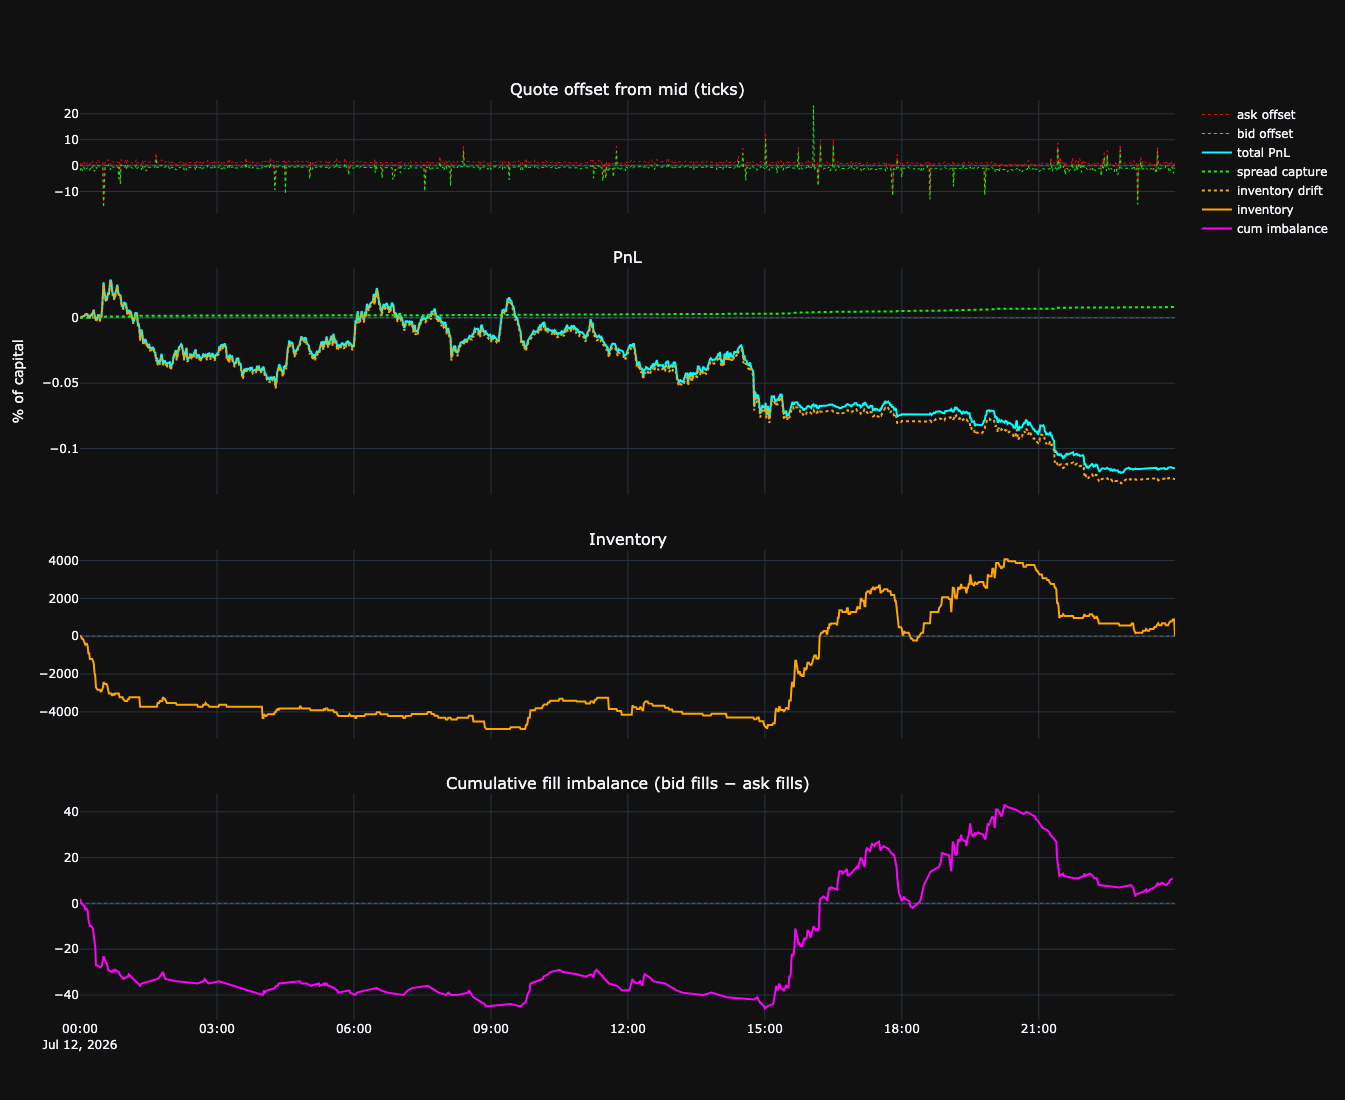

In [19]:
s.plot(tick_size=1e-6).show()